
8-Bit Quantization
----------------------------------------
Scale : 0.018897638
q_min : -127
q_max : 127

Quantized Tensor
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]

Dequantized Tensor
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]

MAE : 0.0037007749
MSE : 2.1638e-05
Maximum Error : 0.007874012

6-Bit Quantization
----------------------------------------
Scale : 0.077419356
q_min : -31
q_max : 31

Quantized Tensor
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]

Dequantized Tensor
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]

MAE : 0.015161285
MSE : 0.00036316324
Maximum Error : 0.032258064

4-Bit Quantization
----------------------------------------
Scale : 0.34285715
q_min : -7
q_max : 7

Quantized Tensor
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]

Dequantized Tensor
[[-1.7142857  -1.0285715   0.          0.6857143

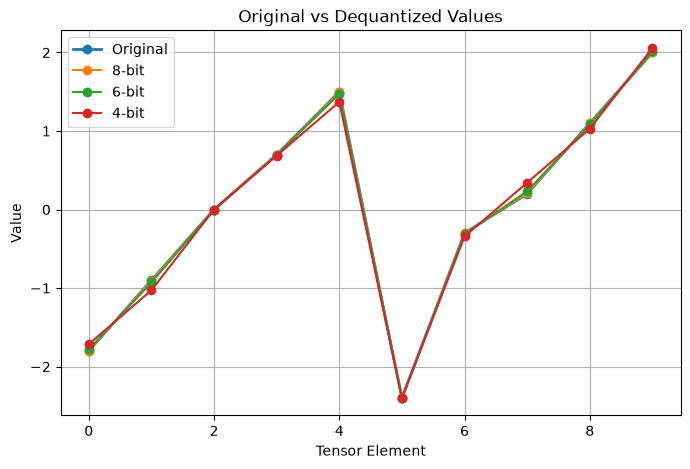

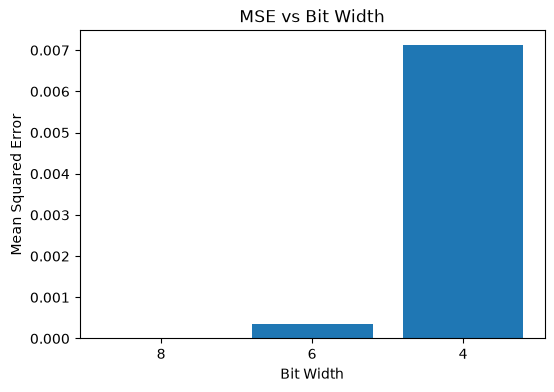

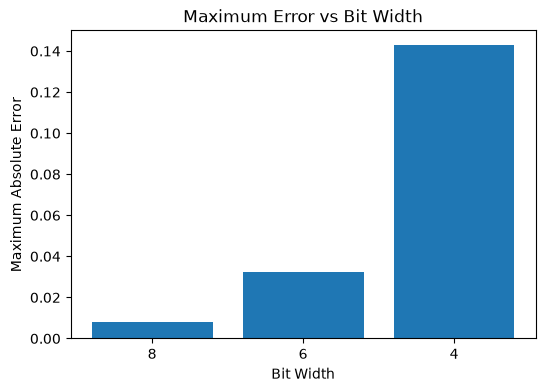

In [1]:
# Task 4: Quantization Error at Different Bit Widths

## Objective

#The objective of this task is to study how quantization error changes when the number of bits used for quantization is reduced.

#Symmetric quantization is implemented using three different bit widths:
#- 8-bit
# 6-bit
# 4-bit

#The reconstructed tensors are compared with the original tensor using different error metrics. Finally, graphs are plotted to visualize the relationship between bit width and quantization error.

import numpy as np
import matplotlib.pyplot as plt
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)
def quantize_at_bitwidth(tensor, bits):
    """
    Perform symmetric quantization for a given bit width.
    Returns:
        quantized_tensor
        dequantized_tensor
        scale
        q_min
        q_max
    """

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    max_abs = np.max(np.abs(tensor))

    scale = max_abs / q_max

    quantized = np.round(tensor / scale)
    quantized = np.clip(quantized, q_min, q_max)
    quantized = quantized.astype(np.int8)

    dequantized = quantized.astype(np.float32) * scale

    return quantized, dequantized, scale, q_min, q_max

bit_widths = [8, 6, 4]

results = {}

print("=" * 90)

for bits in bit_widths:

    q_tensor, dq_tensor, scale, q_min, q_max = quantize_at_bitwidth(tensor, bits)

    error = tensor - dq_tensor

    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    max_error = np.max(np.abs(error))

    levels = q_max - q_min + 1

    results[bits] = {
        "quantized": q_tensor,
        "dequantized": dq_tensor,
        "scale": scale,
        "mae": mae,
        "mse": mse,
        "max_error": max_error,
        "q_min": q_min,
        "q_max": q_max,
        "levels": levels
    }

    print(f"\n{bits}-Bit Quantization")
    print("-" * 40)

    print("Scale :", scale)
    print("q_min :", q_min)
    print("q_max :", q_max)

    print("\nQuantized Tensor")
    print(q_tensor)

    print("\nDequantized Tensor")
    print(dq_tensor)

    print("\nMAE :", mae)
    print("MSE :", mse)
    print("Maximum Error :", max_error)

print("=" * 90)

plt.figure(figsize=(8,5))

original = tensor.flatten()

plt.plot(original, marker='o', linewidth=2, label="Original")

for bits in bit_widths:
    plt.plot(
        results[bits]["dequantized"].flatten(),
        marker='o',
        label=f"{bits}-bit"
    )

plt.title("Original vs Dequantized Values")
plt.xlabel("Tensor Element")
plt.ylabel("Value")
plt.grid(True)
plt.legend()

plt.show()

mse_values = [results[b]["mse"] for b in bit_widths]

plt.figure(figsize=(6,4))

plt.bar(
    [str(b) for b in bit_widths],
    mse_values
)

plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Mean Squared Error")

plt.show()

max_errors = [results[b]["max_error"] for b in bit_widths]

plt.figure(figsize=(6,4))

plt.bar(
    [str(b) for b in bit_widths],
    max_errors
)

plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")

plt.show()

# Observations

#- As the bit width decreases, the number of available quantization levels also decreases.
# The 8-bit quantization provides the smallest reconstruction error because it has the highest precision.
#- The 6-bit quantization introduces a slightly larger error but still preserves the overall shape of the original tensor.
#- The 4-bit quantization has the largest reconstruction error due to the limited number of representable values.
#- The plotted graphs clearly show that reducing the bit width increases both the Mean Squared Error (MSE) and the Maximum Absolute Error.
#- Lower bit widths reduce model size and memory usage but also reduce numerical accuracy.

# Conclusion

#In this task, symmetric quantization was implemented for 8-bit, 6-bit, and 4-bit representations. The comparison showed that higher bit widths preserve the original tensor more accurately, while lower bit widths introduce larger quantization errors. This demonstrates the trade-off between model size and accuracy, which is an important consideration when optimizing deep learning models for deployment on resource-constrained devices.

